In [1]:
# load autoreload
%load_ext autoreload
# autoreload 2
%autoreload 2
import matplotlib.pyplot as plt
import yaml
import os
import numpy as np
import glob
import pandas as pd
from unifigs.scanplotter import ScanPlotter
from NNMFit.utilities import ScanHandler, PseudoexpHandler, load_pickle
# use the latex.mplstyle matplotlib style:
plt.style.use('/home/pfuerst/software/tools/matplotlib_tools/unifigs/unifigs/latex.mplstyle')
# plt.style.use("default")

with open("/home/pfuerst/software/tools/matplotlib_tools/unifigs/unifigs/parameter_plot_config.yaml", "r", encoding="utf-8") as stream:
    parameter_plot_config = yaml.safe_load(stream)[
        "Parameters"] 

%matplotlib inline

In [14]:
# collect tha 2D fits for now:
path_step0 ="/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20"
scan_names = ["nbestfit20_scan_astro_gamma_1D_10steps_round2"]

In [15]:
names = [
    "nbestfit20_scan_astro_gamma_1D_10steps_round2",
]

In [16]:
# get matplotlib color cycle:
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

all_hdls_leff = {}

for i, name in enumerate(names):
    all_hdls_leff[name] = {}

    # asimov
    current_path_asimov = os.path.join(path_step0, name)
    print(name)
    print(current_path_asimov)
    if glob.glob(os.path.join(current_path_asimov, 'FitRes*')):
        print("--- found fits")
        all_hdls_leff[name]["asimov_hdl"] = ScanHandler(
            current_path_asimov, force_read=False
        )

        all_hdls_leff[name]["asimov_settings"] = {
            "color": color_cycle[i],
            "label": name,
            "alpha": 0.8,
            "linewidth": 1.0,
            "marker": ".",
        }

    # pseudoexp
    # todo?

nbestfit20_scan_astro_gamma_1D_10steps_round2
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20/nbestfit20_scan_astro_gamma_1D_10steps_round2
--- found fits


In [9]:
combos = {
    "2D":
        [
            "nbestfit20_scan_astro_gamma_1D_10steps_round2",
        ],
}

In [41]:
# plot all param distributions just for the lulz

parameter_plot_config = {
    'CR_grad':
        {
            'color': '#bcbd22',
            'label': 'CR Model Interp.',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [-1, 2]
        },
    'delta_gamma':
        {
            'color': '#ff7f0e',
            'label': 'CR $\\Delta \\gamma$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [-0.15, 0.15]
        },
    'conv_norm':
        {
            'color': 'royalblue',
            'label': '$\\Phi_{\\mathrm{Conventional}}$',
            'linestyle': '-',
            'ylims': [0, 40],
            'xlims': [1, 2.5]
        },
    'muon_norm':
        {
            'color': 'xkcd:taupe',
            'label': '$\\Phi_{\\mu, \\mathrm{Tracks}}$',
            'linestyle': ':',
            'ylims': [0, 10],
            'xlims': [0, 2.5]
        },
    'muongun_norm':
        {
            'color': 'xkcd:taupe',
            'label': '$\\Phi_{\\mu, \\mathrm{Cscd.}}$',
            'linestyle': '-.',
            'ylims': [0, 30],
            'xlims': [0.9, 1.5]
        },
    'prompt_norm':
        {
            'color': 'turquoise',
            'label': '$\\Phi_{\\mathrm{Prompt}}$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [0, 6]
        },
    'barr_h':
        {
            'color': 'firebrick',
            'label': 'Barr $H$',
            'linestyle': ':',
            'ylims': [0, 5],
            'xlims': [-0.1, 0.1]
        },
    'barr_w':
        {
            'color': 'firebrick',
            'label': 'Barr $W$',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [-0.5, 0.5]
        },
    'barr_y':
        {
            'color': 'firebrick',
            'label': 'Barr $Y$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [-0.6, 0.6]
        },
    'barr_z':
        {
            'color': 'firebrick',
            'label': 'Barr $Z$',
            'linestyle': '-',
            'ylims': [0, 10],
            'xlims': [-0.3, 0.2]
        },
    'dom_eff':
        {
            'color': 'forestgreen',
            'label': 'Opt. Efficiency',
            'linestyle': ':',
            'ylims': [0, 50],
            'xlims': [0.97, 1.13]
        },
    'ice_abs':
        {
            'color': 'forestgreen',
            'label': 'Ice Absorption',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [0.97, 1.13]
        },
    'ice_holep0':
        {
            'color': 'forestgreen',
            'label': 'Ice Hole $p_0$',
            'linestyle': '-',
            'ylims': [0, 500],
            'xlims': [-0.5, 0.5]
        },
    'ice_holep1':
        {
            'color': 'forestgreen',
            'label': 'Ice Hole $p_1$',
            'linestyle': ':',
            'ylims': [0, 200],
            'xlims': [-0.15, -0.03]
        },
    'ice_scat':
        {
            'color': 'forestgreen',
            'label': 'Ice Scattering',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [0.97, 1.16]
        },
    'effective_veto':
        {
            'color': 'grey',
            'label': 'Effective Veto',
            'linestyle': '-',
            'ylims': [0, 50],
            'xlims': [-1.7, 1.7]
        },
    'llh':
        {
            'color': 'black',
            'label': '$-\\log(\\mathcal{L})$',
            'linestyle': '-',
            'ylims': [0, 10]
        }
}

In [17]:
parameter_plot_config = {
    'astro_norm':
        {
            'color': '#bcbd22',
            'label': 'CR Model Interp.',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [0, 4]
        },
    'gamma_astro':
        {
            'color': '#ff7f0e',
            'label': 'CR $\\Delta \\gamma$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [2.5, 3.0]
        },
}

In [18]:
scanplotter = ScanPlotter.from_dict(
    all_hdls_leff, override_parameter_plot_config=parameter_plot_config
)

In [19]:
def format_label(label):
    return label.replace("inject_", "inject ").replace("_fit_", ", fit ")

['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


KeyError: 'ice_crystal'

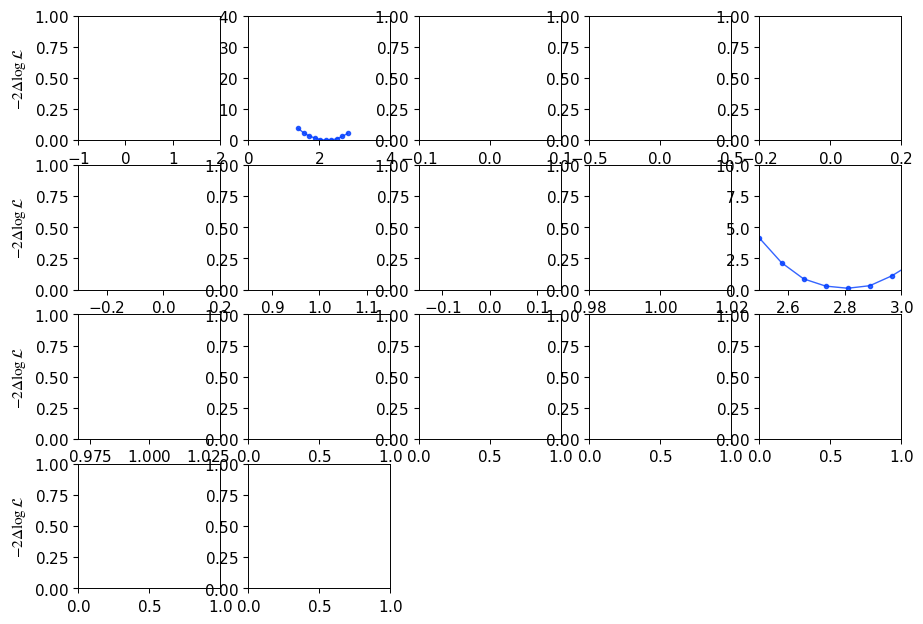

In [20]:
for name, scans_to_plot in combos.items():
    fig, handles, labels = scanplotter.plot_scan_matrix(
        scans_to_plot=scans_to_plot,
        do_asimov=True,
        do_pseudoexp=False,
        # nbins=25,
        width_scale=1.9,
        height_scale=0.7,
        remove_peaks=False,
        default_ylims=True,
        plot_inject=False,
    )
    labels = [format_label(label) for label in labels]
    # edit the hspace and wspaces between subplots:
    fig.subplots_adjust(hspace=0.25, wspace=0.3)
    plt.tight_layout()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.03),
        ncol=len(handles),
        frameon=False
    )
    # axes = fig.axes
    # axes[0].axvline(1.0, color='black', linestyle='--')
    # plt.savefig(
    #     f"/home/pfuerst/documentation/GalacticCombinedFit_wiki/plots/confusion/ice/DELETE.png",
    #     bbox_inches='tight'
    # )
    plt.show()